[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AnFreTh/STREAM/blob/main/docs/notebooks/examples.ipynb)
[![Open On GitHub](https://img.shields.io/badge/Open-on%20GitHub-blue?logo=GitHub)](https://github.com/AnFreTh/STREAM/blob/main/docs/notebooks/examples.ipynb)

# Examples

**Note**: Make sure the `nltk` dependencies are installed. If not, please run the following command:
```python
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
```

In [28]:
# uncomment the below line if running in Colab
# package neeeds to be installed for the notebook to run

# ! pip install -U stream_topic

In [29]:
import warnings

warnings.filterwarnings("ignore")

In [30]:
from stream_topic.models import ETM
from stream_topic.utils import TMDataset

In [ ]:
dataset = TMDataset()
dataset.fetch_dataset("BBC_News")
dataset.preprocess(
    model_type="ETM",
    remove_top_frequent_percent=10,  # Removes top 10% most frequent words
    custom_stopwords=["said", "would", "people", "new", "year", "Year", "YEAR"],
)

2025-07-03 15:41:24.669 | INFO     | stream_topic.utils.dataset:fetch_dataset:119 - Fetching dataset: BBC_News
2025-07-03 15:41:24.898 | INFO     | stream_topic.utils.data_downloader:load_custom_dataset_from_url:331 - Downloading dataset from github
2025-07-03 15:41:25.145 | INFO     | stream_topic.utils.data_downloader:load_custom_dataset_from_url:333 - Dataset downloaded successfully at ~/stream_topic_data/
2025-07-03 15:41:25.399 | INFO     | stream_topic.utils.data_downloader:load_custom_dataset_from_url:361 - Downloading dataset info from github
2025-07-03 15:41:25.528 | INFO     | stream_topic.utils.data_downloader:load_custom_dataset_from_url:363 - Dataset info downloaded successfully at ~/stream_topic_data/
Preprocessing documents: 100%|██████████| 2225/2225 [00:08<00:00, 251.76it/s]


In [32]:
model = ETM(encoder_dim=512, embed_size=128)

model.fit(
    dataset,
    n_topics=10,
    max_epochs=5000,
    lr=1e-4,
    batch_size=128,
)

2025-07-03 15:41:34.402 | INFO     | stream_topic.models.etm:_initialize_datamodule:271 - --- Initializing Datamodule for ETM ---
2025-07-03 15:41:34.552 | INFO     | stream_topic.models.etm:_initialize_trainer:227 - --- Initializing Trainer for ETM ---
Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2025-07-03 15:41:34.558 | INFO     | stream_topic.models.etm:fit:408 - --- Training ETM topic model ---

  | Name           | Type       | Params | Mode 
------------------------------------------------------
0 | model          | ETMBase    | 4.3 M  | train
1 | model.encoder1 | Sequential | 3.5 M  | train
2 | model.fc_mu    | Linear     | 5.1 K  | train
3 | model.fc_var   | Linear     | 5.1 K  | train
-------------------------------------------------

Epoch 1119: 100%|██████████| 14/14 [00:00<00:00, 87.51it/s, v_num=39, train_loss_step=1.03e+3, val_loss_step=1.04e+3, val_loss_epoch=1.12e+3, train_loss_epoch=1.1e+3] 


2025-07-03 15:45:14.663 | INFO     | stream_topic.models.etm:fit:424 - --- Training completed successfully. ---


## Evaluate

In [33]:
from stream_topic.metrics import NPMI, ISIM

topics = model.get_topics()

metric = NPMI(dataset)
metric.score(topics)

np.float64(-0.08728)

In [34]:
isim_metric = ISIM()
isim_metric.score(topics)

0.2287070035934448

## Visualize

In [35]:
from stream_topic.visuals import visualize_topic_model

visualize_topic_model(
    model,
    dataset=dataset,
    reduce_first=True,
    port=8051,
)

2025-07-03 15:45:16.144 | INFO     | stream_topic.utils.data_downloader:load_custom_dataset_from_url:302 - Downloading embeddings from github
2025-07-03 15:45:16.557 | INFO     | stream_topic.utils.data_downloader:load_custom_dataset_from_url:304 - Embeddings  downloaded successfully at ~/stream_topic_data/


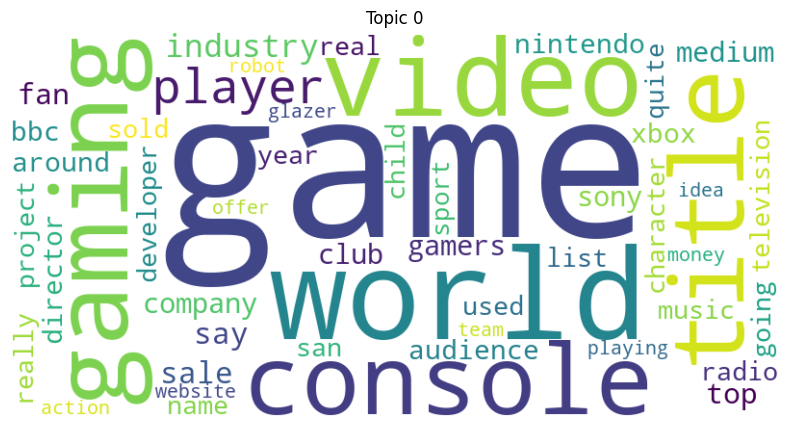

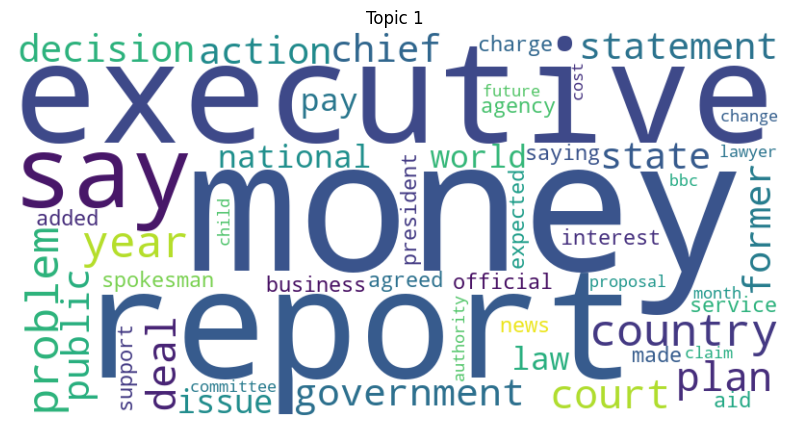

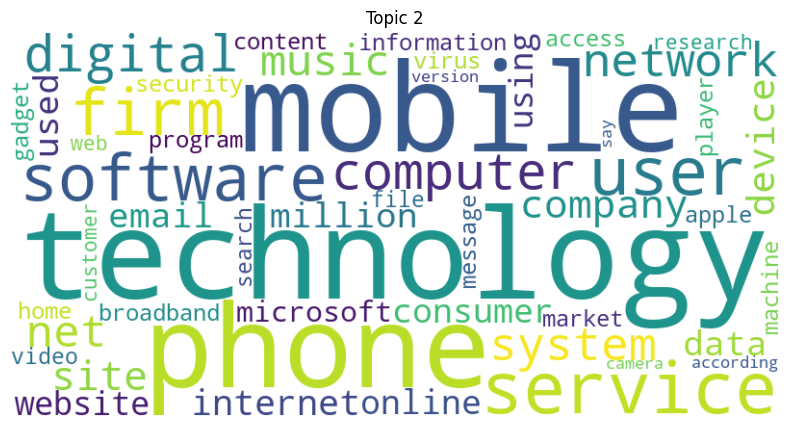

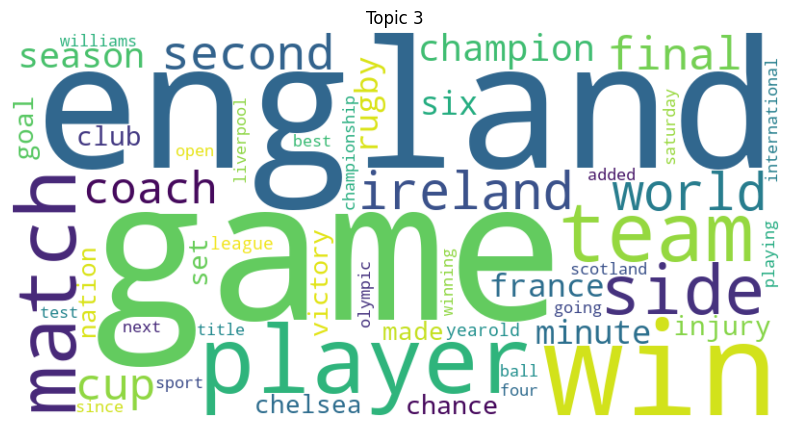

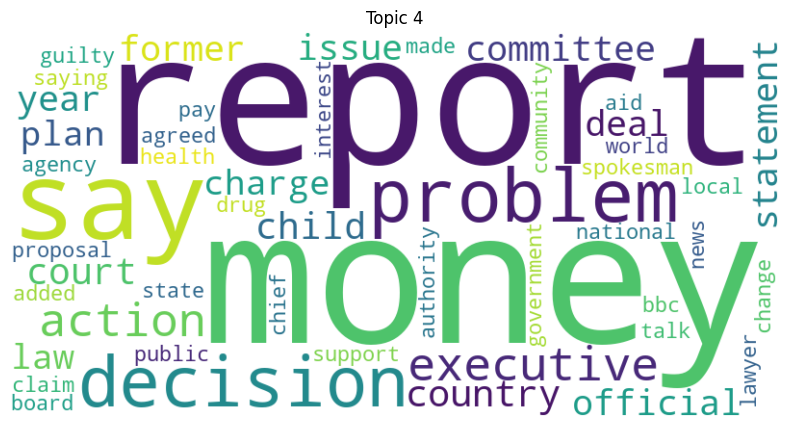

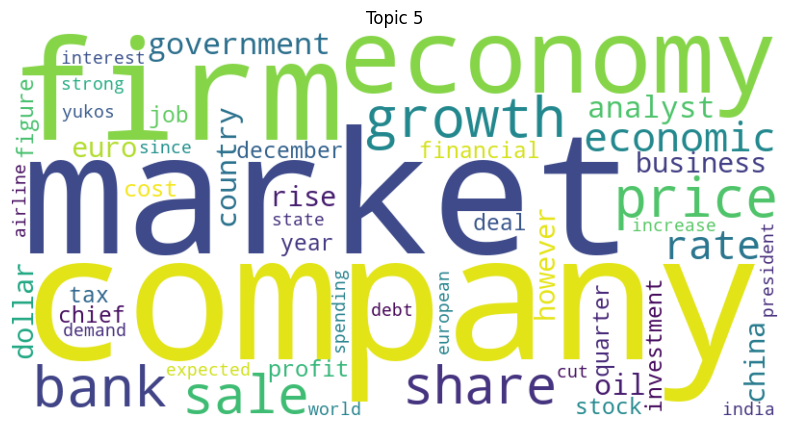

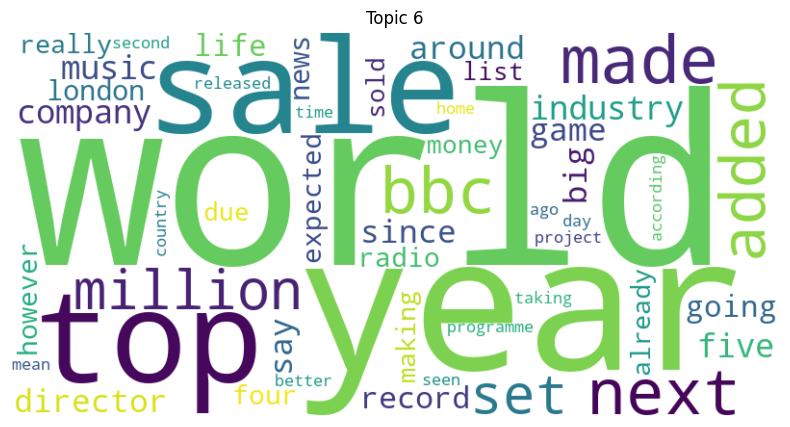

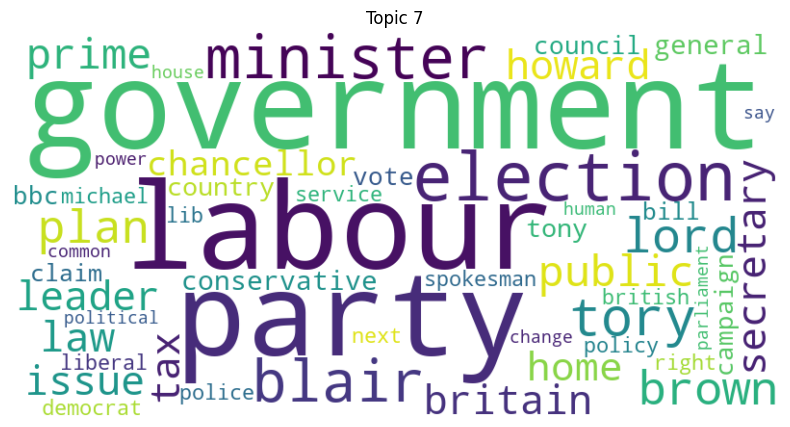

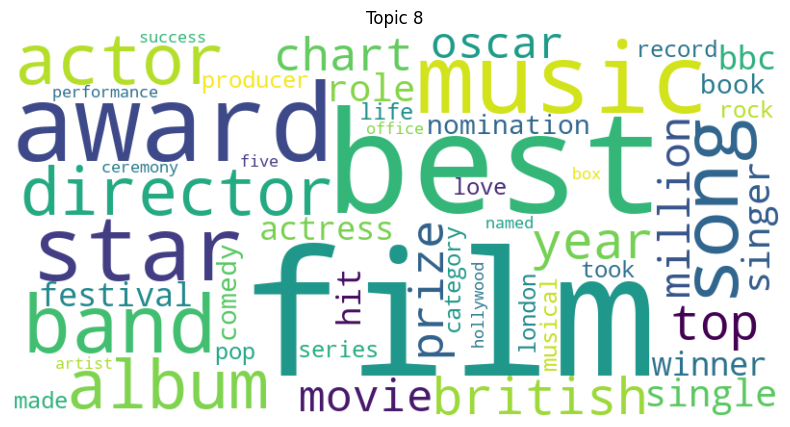

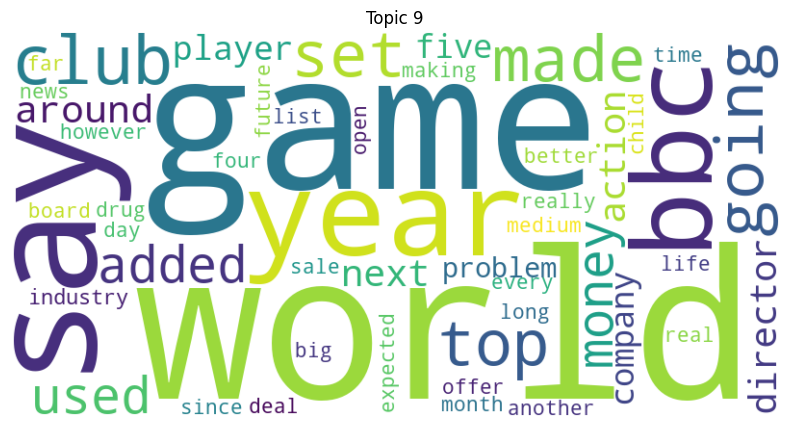

In [36]:
from stream_topic.visuals import visualize_topics_as_wordclouds

visualize_topics_as_wordclouds(model)